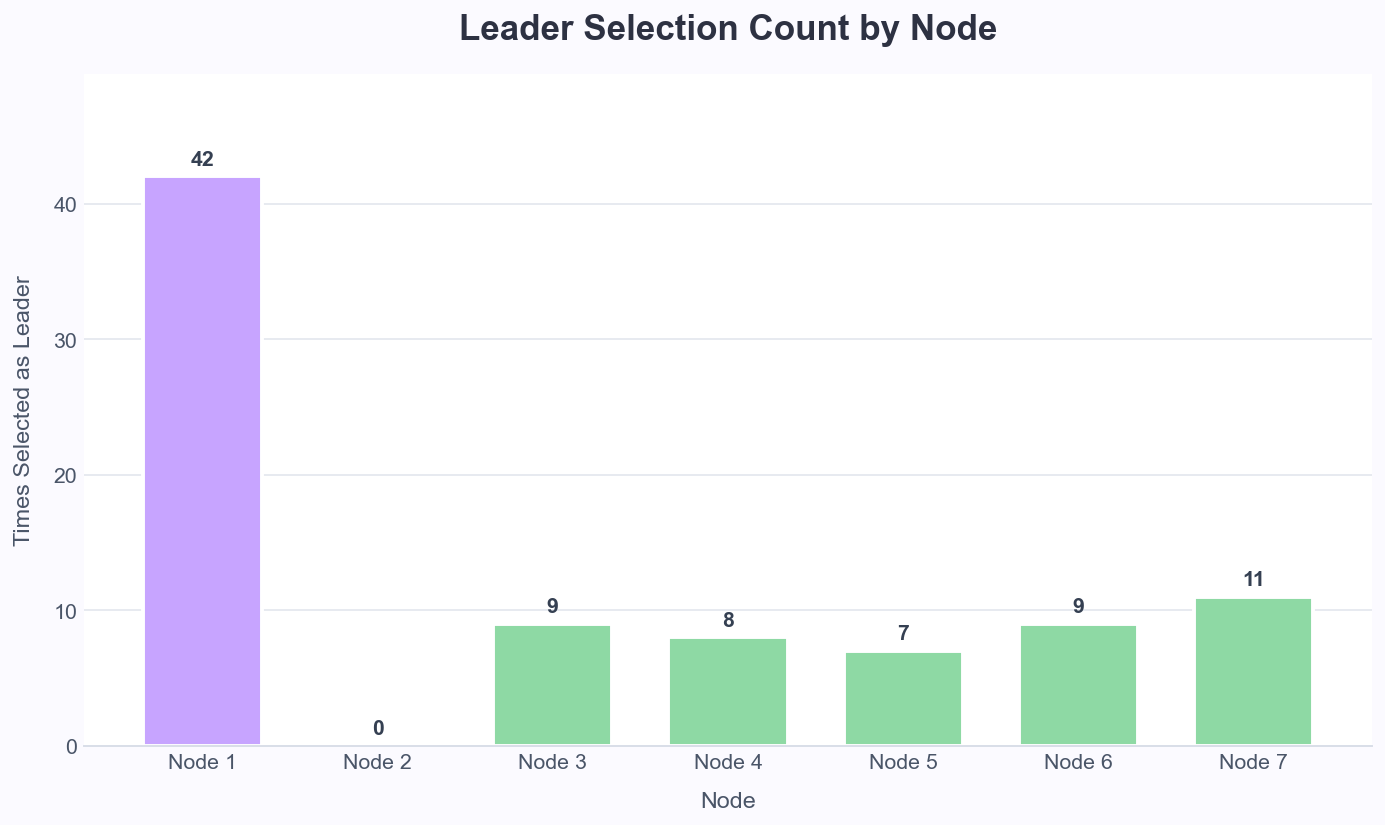

In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt

data_path = Path('leader_counts200-500.json')
with data_path.open() as file:
    data = json.load(file)

leaders = sorted(data['leaders'], key=lambda item: item['node_id'])
node_ids = [leader['node_id'] for leader in leaders]
leader_counts = [leader['times_leader'] for leader in leaders]

pastel_purple = '#C7A4FF'
pastel_green = '#8ED9A4'
colors = [pastel_purple if node_id == 1 else pastel_green for node_id in node_ids]

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 6), dpi=140)
fig.patch.set_facecolor('#FBFAFF')
ax.set_facecolor('#FFFFFF')

bars = ax.bar(
    [f'Node {node_id}' for node_id in node_ids],
    leader_counts,
    color=colors,
    edgecolor='#FFFFFF',
    linewidth=2,
    width=0.68,
)

ax.bar_label(bars, padding=4, fontsize=11, color='#354052', fontweight='bold')
ax.set_title('Leader Selection Count by Node', fontsize=18, fontweight='bold', color='#2D3142', pad=18)
ax.set_xlabel('Node', fontsize=12, color='#4A5568', labelpad=10)
ax.set_ylabel('Times Selected as Leader', fontsize=12, color='#4A5568', labelpad=10)
ax.set_ylim(0, max(leader_counts) * 1.18 if leader_counts else 1)

ax.grid(axis='y', color='#E7EAF0', linewidth=1)
ax.grid(axis='x', visible=False)
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#D9DEE8')
ax.tick_params(axis='both', colors='#4A5568', labelsize=11)

plt.tight_layout()
plt.show()
